In [44]:
import requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import platform

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler

In [45]:
if platform.system() == 'Windows':
    plt.rc('font', family = 'Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False

In [46]:
url = "https://api.thingspeak.com/channels/12397/feeds.json?results=500"
res = requests.get(url)
data = res.json()
data

{'channel': {'id': 12397,
  'name': 'WeatherStation',
  'description': 'MathWorks Weather Station, West Garage, Natick, MA 01760, USA',
  'latitude': '42.299676',
  'longitude': '-71.350525',
  'field1': 'Wind Direction (North = 0 degrees)',
  'field2': 'Wind Speed (mph)',
  'field3': '% Humidity',
  'field4': 'Temperature (F)',
  'field5': 'Rain (Inches/minute)',
  'field6': 'Pressure ("Hg)',
  'field7': 'Power Level (V)',
  'field8': 'Light Intensity',
  'created_at': '2014-05-20T21:50:32Z',
  'updated_at': '2025-10-02T21:56:57Z',
  'elevation': '60',
  'last_entry_id': 5605906},
 'feeds': [{'created_at': '2026-05-26T18:45:38Z',
   'entry_id': 5605407,
   'field1': '143',
   'field2': '3.8',
   'field3': '0',
   'field4': '0.1',
   'field5': '0',
   'field6': '29.79',
   'field7': '0',
   'field8': '0'},
  {'created_at': '2026-05-26T18:46:38Z',
   'entry_id': 5605408,
   'field1': '113',
   'field2': '5.1',
   'field3': '0',
   'field4': '0.1',
   'field5': '0',
   'field6': '29.79',

- field1 : 풍향 → 도 단위 ( 0 ~ 360 )
- field2 : 풍속 → m/s
- field3 : 상대 습도 → %
- field4 : 기온 → ℉
- field5 : 강우량 → ㎜
- field6 : 기압 → ㎪
- field7 : 조도/일사량 → 빛의 세기
- field8 : 센서 배터리의 전압 → 장비 전원 상태 (V)

In [47]:
df = pd.DataFrame(data['feeds'])
df.head(10)

,created_at,entry_id,field1,field2,field3,field4,field5,field6,field7,field8
0,2026-05-26T18:45:38Z,5605407,143,3.8,0,0.1,0,29.79,0,0
1,2026-05-26T18:46:38Z,5605408,113,5.1,0,0.1,0,29.79,0,0
2,2026-05-26T18:47:38Z,5605409,113,7.3,0,0.1,0,29.78,0,0
3,2026-05-26T18:48:38Z,5605410,127,8.9,0,0.1,0,29.78,0,0
4,2026-05-26T18:49:38Z,5605411,134,6.4,0,0.1,0,29.78,0,0
5,2026-05-26T18:50:38Z,5605412,166,9.6,0,0.1,0,29.78,0,0
6,2026-05-26T18:51:38Z,5605413,163,7.6,0,0.1,0,29.78,0,0
7,2026-05-26T18:52:38Z,5605414,144,3.9,0,0.1,0,29.78,0,0
8,2026-05-26T18:53:38Z,5605415,113,5.7,0,0.1,0,29.78,0,0
9,2026-05-26T18:54:38Z,5605416,113,5.5,0,0.1,0,29.78,0,0


In [48]:
df = df[['created_at', 'field2']]
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   created_at  500 non-null    str  
 1   field2      500 non-null    str  
dtypes: str(2)
memory usage: 7.9 KB


In [49]:
df.columns = ['Time', 'value']
df.describe()

,Time,value
count,500,500
unique,500,76
top,2026-05-26T18:45:38Z,4.1
freq,1,19


In [50]:
df['value'] = pd.to_numeric(df['value'])
# astype 말고 to_numeric을 사용하면 errors 매개변수를 사용할 수 있음
df.describe()

,value
count,500.000000
mean,5.407600
std,1.545081
min,2.200000
25%,4.200000
50%,5.200000
75%,6.300000
max,11.900000


In [51]:
scaler = MinMaxScaler()
df['scaled_value'] = scaler.fit_transform(df[['value']])
df.head()

,Time,value,scaled_value
0,2026-05-26T18:45:38Z,3.8,0.164948
1,2026-05-26T18:46:38Z,5.1,0.298969
2,2026-05-26T18:47:38Z,7.3,0.525773
3,2026-05-26T18:48:38Z,8.9,0.690722
4,2026-05-26T18:49:38Z,6.4,0.432990


In [52]:
features = df[['scaled_value']].values
features

array([[0.16494845],
       [0.29896907],
       [0.5257732 ],
       [0.69072165],
       [0.43298969],
       [0.7628866 ],
       [0.55670103],
       [0.17525773],
       [0.36082474],
       [0.34020619],
       [0.28865979],
       [0.30927835],
       [0.25773196],
       [0.20618557],
       [0.22680412],
       [0.15463918],
       [0.04123711],
       [0.12371134],
       [0.2371134 ],
       [0.11340206],
       [0.15463918],
       [0.13402062],
       [0.25773196],
       [0.42268041],
       [0.57731959],
       [0.26804124],
       [0.49484536],
       [0.48453608],
       [0.48453608],
       [0.59793814],
       [0.6185567 ],
       [0.95876289],
       [0.58762887],
       [0.71134021],
       [0.50515464],
       [0.45360825],
       [0.39175258],
       [0.08247423],
       [0.41237113],
       [0.59793814],
       [0.15463918],
       [0.32989691],
       [0.32989691],
       [0.26804124],
       [0.2371134 ],
       [0.29896907],
       [0.35051546],
       [0.185

In [53]:
class WindowDS(Dataset):
    def __init__(self, _x, _window):
        self.data = _x
        self.window = _window
        self.n = len(_x) - _window
    def __len__(self):
        return self.n
    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window]
        y = self.data[idx + self.window]
        x_tensor = torch.from_numpy(x).float()
        y_tensor = torch.tensor(y).float()
        return x_tensor, y_tensor

In [54]:
sensor_ds = WindowDS(features, 10)
train_dl = DataLoader(sensor_ds, batch_size=32, shuffle=False)

In [55]:
class SensorLSTM(nn.Module):
    def __init__(
            self,
            input_size,
            hidden_size
    ):
        super(SensorLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.model = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        pred = self.model(h_n[-1])
        return pred

In [56]:
model = SensorLSTM(1, 16)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [57]:
model.train()

for epoch in range(30):
    total_loss, total_n = 0.0, 0
    for x, y in train_dl:
        pred = model(x)
        loss = criterion(pred, y)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * y.size(0)
        total_n += y.size(0)
    train_loss = total_loss / max(total_n, 1)

    if (epoch+1) % 5 == 0:
        print(f"Epoch: {epoch+1} / train_MSE : {round(train_loss, 6)}")

Epoch: 5 / train_MSE : 0.025018
Epoch: 10 / train_MSE : 0.022667
Epoch: 15 / train_MSE : 0.020902
Epoch: 20 / train_MSE : 0.020249
Epoch: 25 / train_MSE : 0.020025
Epoch: 30 / train_MSE : 0.019898


In [58]:
# 예측값 → 기존의 데이터를 이용해서 예측 (원본의 데이터 모두를 예측)

model.eval()

full_loader = DataLoader(sensor_ds, batch_size = len(sensor_ds), shuffle = False)
x, y = next(iter(full_loader))

with torch.no_grad():
    pred = model(x)
    errors = torch.abs(y - pred).numpy()

# 오차의 분포에서 상위 5% 지점을 이상치 임계값으로 설정
threshold = np.percentile(errors, 95)
anomalies = errors > threshold

In [59]:
print('임계값:', threshold)

임계값: 0.27109927


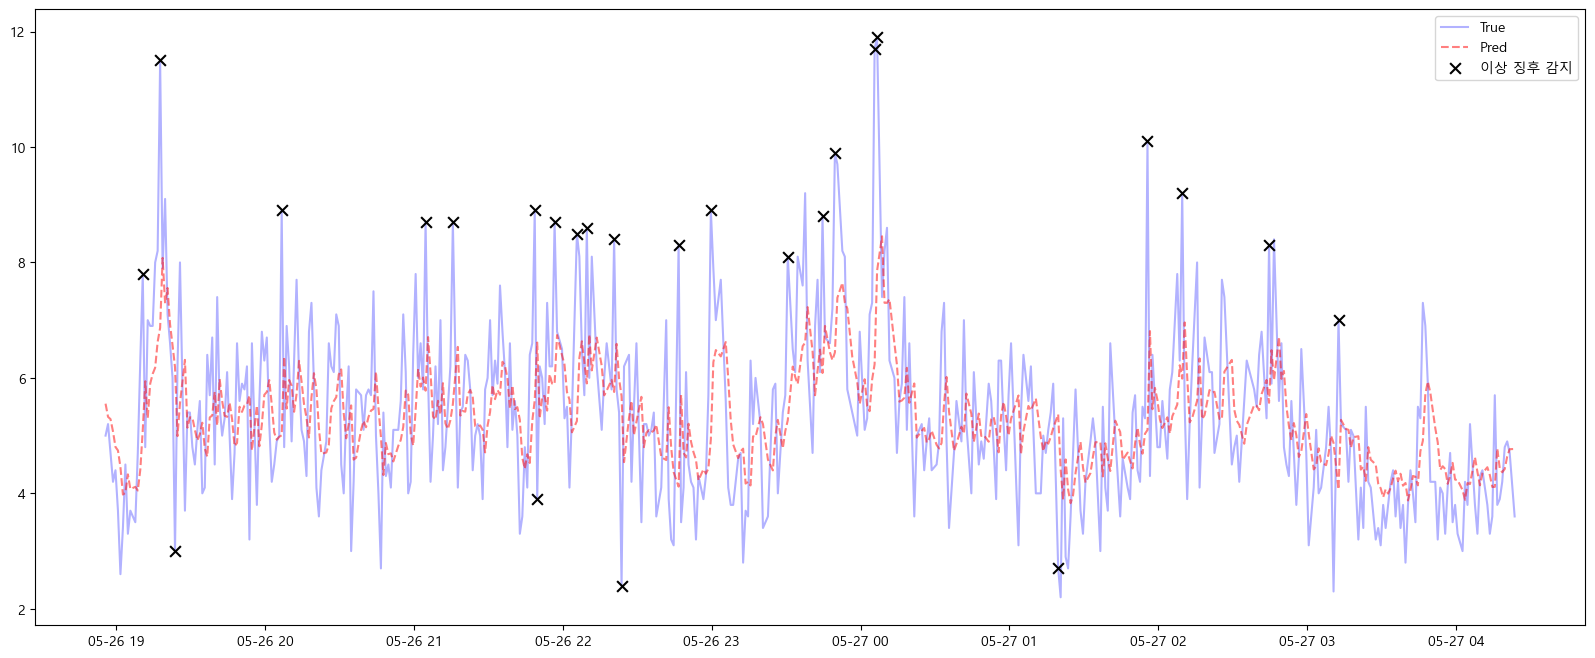

In [61]:
true_y = scaler.inverse_transform(y)
pred_y = scaler.inverse_transform(pred)
df['Time'] = pd.to_datetime(df['Time'])
plot_x = df['Time'].iloc[10:].values

plt.figure(figsize=(20, 8))
plt.plot(plot_x, true_y, label = 'True', color='blue', alpha=0.3)
plt.plot(plot_x, pred_y, label = 'Pred', color = 'red', alpha = 0.5, linestyle = '--')

# 이상치가 감지된 인덱스를 추출하고 산점도 그래프를 추가하여 이상치 표시
anomaly_idx = np.where(anomalies)[0]
if len(anomaly_idx) > 0:
    plt.scatter(
        plot_x[anomaly_idx],
        true_y[anomaly_idx],
        color='black',
        label = '이상 징후 감지',
        s = 60,
        marker = 'x',
        zorder = 5
    )

plt.legend()
plt.show()